In [2]:
# Imports principaux pour l'étape 2 : MLflow + modèle baseline

import pandas as pd
import numpy as np

import mlflow
import mlflow.lightgbm

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("MLflow version :", mlflow.__version__)

MLflow version : 3.14.0


In [ ]:
# ============================================================
# Chargement du dataset final construit à l'étape 1
# Le dataset contient :
# - application_train
# - application_test
# - bureau
# - bureau_balance
# - previous_application
# - POS_CASH_balance
# - installments_payments
# - credit_card_balance
#
# Le fichier est stocké au format Parquet pour réduire
# l'utilisation mémoire et accélérer les lectures.
# ============================================================

df = pd.read_parquet(
    "../data/processed/home_credit_features.parquet"
)

print("Shape :", df.shape)

Shape : (356251, 797)


In [6]:
# ============================================================
# Séparation du dataset en :
#
# - train_df : observations possédant TARGET
# - test_df  : observations sans TARGET
#
# application_test ne possède pas la variable cible,
# elle servira uniquement pour les prédictions finales.
# ============================================================

train_df = df[df["TARGET"].notna()]
test_df = df[df["TARGET"].isna()]

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)

Train shape : (307507, 797)
Test shape  : (48744, 797)


In [7]:
# ============================================================
# Construction :
#
# y = variable cible
# X = variables explicatives
#
# On retire :
# - TARGET : variable à prédire
# - SK_ID_CURR : identifiant client
# ============================================================

# Variable cible
y = train_df["TARGET"]

# Variables explicatives
X = train_df.drop(
    columns=["TARGET", "SK_ID_CURR"]
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (307507, 795)
Shape y : (307507,)


In [8]:
# ============================================================
# Vérification rapide des valeurs manquantes
#
# Cette étape permet de connaître le pourcentage moyen
# de NaN présent dans le dataset final.
# ============================================================

missing_rate = X.isna().mean().mean()

print(f"Taux moyen de NaN : {missing_rate:.2%}")

Taux moyen de NaN : 25.99%


In [9]:
# ============================================================
# Séparation Train / Validation
#
# On conserve 20% des données pour évaluer
# la performance du modèle sur des données non vues.
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)

print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)

X_train : (246005, 795)
X_valid : (61502, 795)
y_train : (246005,)
y_valid : (61502,)


In [10]:
# ============================================================
# Analyse du déséquilibre des classes
#
# On mesure la proportion de clients en défaut
# (TARGET = 1) et non défaut (TARGET = 0)
# ============================================================

class_distribution = y.value_counts(normalize=True)

print("Distribution des classes :")
print(class_distribution)

print()
print(f"Classe 0 : {class_distribution[0]:.2%}")
print(f"Classe 1 : {class_distribution[1]:.2%}")

Distribution des classes :
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Classe 0 : 91.93%
Classe 1 : 8.07%


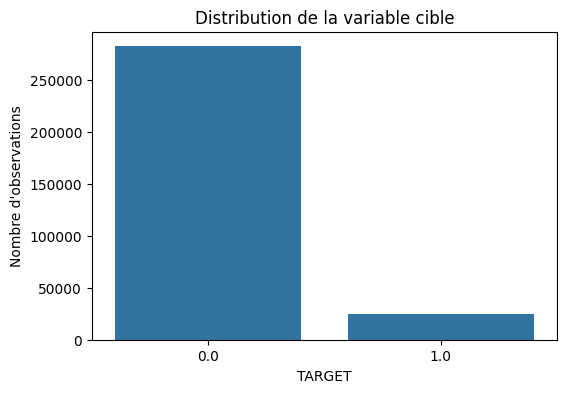

In [11]:
# ============================================================
# Visualisation du déséquilibre des classes
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Distribution de la variable cible")
plt.xlabel("TARGET")
plt.ylabel("Nombre d'observations")

plt.show()

In [12]:
# ============================================================
# Vérification des types de colonnes
# ============================================================

object_cols = X_train.select_dtypes(include=["object"]).columns

print("Nombre de colonnes object :", len(object_cols))

if len(object_cols) > 0:
    print(object_cols.tolist()[:20])

Nombre de colonnes object : 16
['CC_NAME_CONTRACT_STATUS_Active_MIN', 'CC_NAME_CONTRACT_STATUS_Active_MAX', 'CC_NAME_CONTRACT_STATUS_Approved_MIN', 'CC_NAME_CONTRACT_STATUS_Approved_MAX', 'CC_NAME_CONTRACT_STATUS_Completed_MIN', 'CC_NAME_CONTRACT_STATUS_Completed_MAX', 'CC_NAME_CONTRACT_STATUS_Demand_MIN', 'CC_NAME_CONTRACT_STATUS_Demand_MAX', 'CC_NAME_CONTRACT_STATUS_Refused_MIN', 'CC_NAME_CONTRACT_STATUS_Refused_MAX', 'CC_NAME_CONTRACT_STATUS_Sent proposal_MIN', 'CC_NAME_CONTRACT_STATUS_Sent proposal_MAX', 'CC_NAME_CONTRACT_STATUS_Signed_MIN', 'CC_NAME_CONTRACT_STATUS_Signed_MAX', 'CC_NAME_CONTRACT_STATUS_nan_MIN', 'CC_NAME_CONTRACT_STATUS_nan_MAX']


In [13]:
# ============================================================
# Correction des colonnes de type object
#
# LightGBM ne peut pas entraîner un modèle avec des colonnes
# textuelles/object. Ici, les colonnes concernées proviennent
# de variables one-hot agrégées dans credit_card_balance.
#
# On les convertit donc en valeurs numériques.
# ============================================================

object_cols = X_train.select_dtypes(include=["object"]).columns

for col in object_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")

# Vérification après correction
object_cols_after = X_train.select_dtypes(include=["object"]).columns

print("Nombre de colonnes object après correction :", len(object_cols_after))

Nombre de colonnes object après correction : 0


In [16]:
# ============================================================
# Nettoyage des noms de colonnes
#
# LightGBM n'accepte pas certains caractères spéciaux
# dans les noms de features.
#
# On remplace donc tous les caractères problématiques
# par des underscores.
# ============================================================

import re

def clean_feature_names(columns):
    cleaned_columns = []

    for col in columns:
        # Remplacer tous les caractères non alphanumériques par "_"
        clean_col = re.sub(r"[^A-Za-z0-9_]+", "_", col)

        # Supprimer les underscores en début/fin si besoin
        clean_col = clean_col.strip("_")

        cleaned_columns.append(clean_col)

    return cleaned_columns


# Nettoyage des noms de colonnes pour train et validation
clean_columns = clean_feature_names(X_train.columns)

X_train.columns = clean_columns
X_valid.columns = clean_columns

# Vérification rapide
print("Nombre de colonnes X_train :", X_train.shape[1])
print("Nombre de colonnes X_valid :", X_valid.shape[1])
print("Exemple de colonnes nettoyées :")
print(X_train.columns[:10].tolist())

Nombre de colonnes X_train : 795
Nombre de colonnes X_valid : 795
Exemple de colonnes nettoyées :
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH']


In [17]:
# ============================================================
# Première baseline LightGBM
#
# Aucun traitement du déséquilibre des classes.
# Aucun tuning d'hyperparamètres.
#
# Objectif :
# Obtenir une première performance de référence.
# ============================================================

model = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train,
    y_train
)

print("Entraînement terminé.")

Entraînement terminé.


In [18]:
# ============================================================
# Prédictions sur le jeu de validation
# ============================================================

y_pred = model.predict(X_valid)

y_proba = model.predict_proba(X_valid)[:, 1]

print("Prédictions terminées.")

Prédictions terminées.


In [19]:
# ============================================================
# Évaluation de la baseline LightGBM
# ============================================================

auc = roc_auc_score(y_valid, y_proba)

accuracy = accuracy_score(y_valid, y_pred)

precision = precision_score(y_valid, y_pred)

recall = recall_score(y_valid, y_pred)

f1 = f1_score(y_valid, y_pred)

print(f"ROC-AUC   : {auc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

ROC-AUC   : 0.7819
Accuracy : 0.9201
Precision: 0.5714
Recall   : 0.0403
F1-score : 0.0753


In [22]:
# ============================================================
# Premier run MLflow
# ============================================================

mlflow.set_experiment("Home Credit Baseline")

with mlflow.start_run(
    run_name="lightgbm_baseline_v1"
):

    # Paramètres
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)

    # Métriques
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Modèle
    mlflow.lightgbm.log_model(
        model,
        name="model"
    )

print("Run MLflow enregistré.")

2026/06/19 21:26:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run MLflow enregistré.


In [21]:
import mlflow

print("Tracking URI :", mlflow.get_tracking_uri())

for exp in mlflow.search_experiments():
    print(exp.name)

Tracking URI : sqlite:///C:/AI_engineer_training/Projets/Projet_6_Initiez_vous_au_MLOps_partie_1/home-credit-mlops/notebooks/mlflow.db
Home Credit Baseline
Default
